<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Proyecto 3 - Solar Active Regions with SunPy
</h2>

<p>
<b>Tema:</b> análisis estadístico de regiones activas solares a partir de datos tabulares de HEK.
</p>

<p>
<b>Nota:</b> este notebook trabaja con una muestra tabular local ya exportada desde HEK. No usa imágenes.
</p>

</div>



<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
<b>Nota:</b> Este notebook intenta consultar en vivo el catálogo HEK usando SunPy.
</p>

<p>
Si el servicio no responde o la conexión falla, se utiliza como respaldo el archivo local <code>raw_active_regions.csv</code> para garantizar que el pipeline siga siendo reproducible.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
1. Librerías y configuración
</h3>

</div>

In [ ]:
from pathlib import Path #rutas de archivos y carpetas
import sqlite3 #crear y consultar base de datos
from datetime import datetime, UTC #manejar fechas y zona horaria

import numpy as np #op numericas, manejo de valores Nan
import pandas as pd #manejo y analisis de datos tabulares
import matplotlib.pyplot as plt #graf y visualiaciones
import seaborn as sns #crear graficas estadisticas

from astropy.time import #manejar y convertir tiempos astronómicos
from sunpy.net import attrs as #definir atributos para consultas solares
from sunpy.net.hek import HEKClient #consultar HEK
from sunpy.coordinates import sun #cálculos de coordenadas y parámetros solares

sns.set_theme(context='talk', style='whitegrid') #graficas
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path.cwd() #carpeta act de trabajo
RAW_AR_CSV = BASE_DIR / 'raw_ar_hek_optionA_prueba.csv' #ruta region activa
RAW_FL_CSV = BASE_DIR / 'raw_fl_hek_optionA_prueba.csv' #ruta fulguraciones
CURATED_CSV = BASE_DIR / 'active_regions_optionA_prueba.csv'
DB_PATH = BASE_DIR / 'astro_project_optionA_prueba.db'
DASHBOARD_PATH = BASE_DIR / 'dashboard_optionA_prueba.png' #donde se guardará el dashboard

START_DATE = '2014-01-01' #fecha inicial del periodo de análisis
END_DATE = '2014-12-31' #fecha final del periodo de análisis
CHUNK_MONTHS = 1 #dividir las consultas HEK en intervalos de un mes
MAX_RETRIES = 3 #intentos por si falla la consulta

print('Working directory:', BASE_DIR). #mostrar carpeta de trabajo 
print('Date range:', START_DATE, '->', END_DATE) #mostrar el rango temporal

Working directory: /Users/marav.angel/Documents/New project/Sunpy
Date range: 2014-01-01 -> 2014-12-31


/opt/miniconda3/envs/marita/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
2. Stage 1 - Adquisición de datos tabulares
</h3>

<p>
Se cargan metadatos de regiones activas solares previamente obtenidos desde HEK.
</p>

</div>

In [ ]:
def month_ranges(start, end, chunk_months=1):   #divide el rango de fechas en intervalos mensuales
    start_ts = pd.Timestamp(start)  #convierte la fecha inicial a formato Timestamp
    end_ts = pd.Timestamp(end)   #convierte la fecha final a formato Timestamp
    ranges = [] #crea una lista vacía para almacenar los intervalos de fechas
    cursor = start_ts #inicializa el cursor en la fecha de inicio
    while cursor <= end_ts:   #repite el proceso mientras el cursor esté dentro del rango temporal
        chunk_end = (cursor + pd.offsets.MonthEnd(chunk_months)).normalize() #calcula el final del intervalo mensual
        if chunk_end > end_ts: #verifica si el intervalo supera la fecha final
            chunk_end = end_ts #ajusta el inter a la fecha f
        ranges.append((cursor.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d'))) #guarda el intervalo de fechas
        cursor = (chunk_end + pd.Timedelta(days=1)).normalize() #avanza el cursor al dia siguiente
    return ranges #devuelve la lista de rangos temporales

def table_to_dataframe_safe(table): #tabla de Astropy en un DataFrame de pandas de forma ok
    data = {} #pues la data , como un diccionario vacio
    for col in table.colnames: #recorre cada columna en la tabla 
        values = [] #lista para almacenar los valores de la columna 
        for v in table[col]: #recorre cada columna de la tabla
            try:
                values.append(v.item() if hasattr(v, 'item') else v) #extrae el valor nativo si el objeto tiene el método item
            except Exception:
                values.append(str(v))  #convierte el valor a texto si ocurre un error
        data[col] = values 
    return pd.DataFrame(data)

#consulta eventos solares en HEK con reintentos automáticos
def safe_search(client, start, end, event_type):
    last_exc = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return client.search(
                a.Time(start, end),
                a.hek.EventType(event_type)
            )
        except Exception as exc:
            last_exc = exc
            print(f'Intento {attempt} fallo para {event_type} en {start} -> {end}: {exc}')
    raise last_exc

#funciones auxiliares para buscar columnas y convertir valores numéricos
def first_existing_column(df, candidates):
    for name in candidates:
        if name in df.columns:
            return name
    return None

def safe_to_float(value):
    try:
        return float(value)
    except Exception:
        try:
            return float(getattr(value, 'value', np.nan))
        except Exception:
            return np.nan
        
#convierte la clasificación GOES de una fulguración a flujo pico en W/m²
def parse_goes_peak_flux(flare_class):
    if pd.isna(flare_class):
        return np.nan
    flare_class = str(flare_class).strip().upper()
    if len(flare_class) < 2:
        return np.nan
    scale = {'A': 1e-8, 'B': 1e-7, 'C': 1e-6, 'M': 1e-5, 'X': 1e-4}
    letter = flare_class[0]
    number = flare_class[1:]
    if letter not in scale:
        return np.nan
    try:
        return float(number) * scale[letter]
    except Exception:
        return np.nan
    
#limpia y normaliza los datos de regiones activas solares
def normalize_ar_table(raw_df):
    column_map = {
        'ar_noaanum': ['ar_noaanum'],
        'event_starttime': ['event_starttime'],
        'hgs_x': ['hgs_x'],
        'hgs_y': ['hgs_y'],
        'area_atdiskcenter': ['area_atdiskcenter', 'area_raw'],
        'magnetic_classification': ['ar_noaaclass']
    }
    df = pd.DataFrame()
    for target, candidates in column_map.items():
        source = first_existing_column(raw_df, candidates)
        df[target] = raw_df[source] if source is not None else np.nan

    df['event_starttime'] = pd.to_datetime(df['event_starttime'], errors='coerce')
    df['ar_noaanum'] = pd.to_numeric(df['ar_noaanum'], errors='coerce')
    df['hgs_x'] = pd.to_numeric(df['hgs_x'], errors='coerce')
    df['hgs_y'] = pd.to_numeric(df['hgs_y'], errors='coerce')
    df['area_atdiskcenter'] = df['area_atdiskcenter'].apply(safe_to_float)
    df['magnetic_classification'] = df['magnetic_classification'].fillna('Unknown')
    df = df.dropna(subset=['event_starttime'])
    return df

#limpia los datos de fulguraciones y calcula su flujo pico GOES
def normalize_fl_table(raw_df):
    column_map = {
        'ar_noaanum': ['ar_noaanum'],
        'event_starttime': ['event_starttime'],
        'flare_class': ['fl_goescls', 'fl_peakflux']
    }
    df = pd.DataFrame()
    for target, candidates in column_map.items():
        source = first_existing_column(raw_df, candidates)
        df[target] = raw_df[source] if source is not None else np.nan

    df['event_starttime'] = pd.to_datetime(df['event_starttime'], errors='coerce')
    df['ar_noaanum'] = pd.to_numeric(df['ar_noaanum'], errors='coerce')
    df['goes_peak_flux'] = df['flare_class'].apply(parse_goes_peak_flux)
    df = df.dropna(subset=['event_starttime'])
    return df

#inicializa HEK y genera los intervalos mensuales de consulta
client = HEKClient()
ranges = month_ranges(START_DATE, END_DATE, CHUNK_MONTHS)
ranges[:3], len(ranges)

([('2014-01-01', '2014-01-31'),
  ('2014-02-01', '2014-02-28'),
  ('2014-03-01', '2014-03-31')],
 12)

In [ ]:
ar_frames = [] #consulta en HEK las regiones activas (AR) y fulguraciones solares (FL)
fl_frames = []

for start, end in ranges:
    print(f'Consultando AR: {start} -> {end}')
    ar_table = safe_search(client, start, end, 'AR')
    ar_frames.append(table_to_dataframe_safe(ar_table))

    print(f'Consultando FL: {start} -> {end}')
    fl_table = safe_search(client, start, end, 'FL')
    fl_frames.append(table_to_dataframe_safe(fl_table))

#une los resultados de cada intervalo en DataFrames
raw_ar_df = pd.concat(ar_frames, ignore_index=True) if ar_frames else pd.DataFrame()
raw_fl_df = pd.concat(fl_frames, ignore_index=True) if fl_frames else pd.DataFrame()

#guarda los datos crudos y muestra sus dimensiones
raw_ar_df.to_csv(RAW_AR_CSV, index=False)
raw_fl_df.to_csv(RAW_FL_CSV, index=False)

print('AR shape:', raw_ar_df.shape)
print('FL shape:', raw_fl_df.shape)

Consultando AR: 2014-01-01 -> 2014-01-31
Consultando FL: 2014-01-01 -> 2014-01-31
Consultando AR: 2014-02-01 -> 2014-02-28
Consultando FL: 2014-02-01 -> 2014-02-28
Consultando AR: 2014-03-01 -> 2014-03-31
Consultando FL: 2014-03-01 -> 2014-03-31
Consultando AR: 2014-04-01 -> 2014-04-30
Consultando FL: 2014-04-01 -> 2014-04-30
Consultando AR: 2014-05-01 -> 2014-05-31
Consultando FL: 2014-05-01 -> 2014-05-31
Consultando AR: 2014-06-01 -> 2014-06-30
Consultando FL: 2014-06-01 -> 2014-06-30
Consultando AR: 2014-07-01 -> 2014-07-31
Consultando FL: 2014-07-01 -> 2014-07-31
Consultando AR: 2014-08-01 -> 2014-08-31
Consultando FL: 2014-08-01 -> 2014-08-31
Consultando AR: 2014-09-01 -> 2014-09-30
Consultando FL: 2014-09-01 -> 2014-09-30
Consultando AR: 2014-10-01 -> 2014-10-31
Consultando FL: 2014-10-01 -> 2014-10-31
Consultando AR: 2014-11-01 -> 2014-11-30
Consultando FL: 2014-11-01 -> 2014-11-30
Consultando AR: 2014-12-01 -> 2014-12-31
Consultando FL: 2014-12-01 -> 2014-12-31
AR shape: (39849

In [ ]:
import re #importa librerías para limpiar datos, manejar fechas astronómicas y calcular rotaciones de Carrington
import numpy as np
import pandas as pd
from astropy.time import Time
from sunpy.coordinates import sun

#carga nuevamente los datos crudos guardados desde HEK
raw_ar_df = pd.read_csv(RAW_AR_CSV, low_memory=False)
raw_fl_df = pd.read_csv(RAW_FL_CSV, low_memory=False)

#f. auxiliares para encontrar columnas, extraer números y convertir clases GOES a flujo pico
def first_existing_column(df, candidates):
    for name in candidates:
        if name in df.columns:
            return name
    return None

def extract_numeric(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text in {"", "nan", "None", "———", "---"}:
        return np.nan
    match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
    if match:
        try:
            return float(match.group())
        except Exception:
            return np.nan
    return np.nan

def parse_goes_peak_flux(flare_class):
    if pd.isna(flare_class):
        return np.nan
    flare_class = str(flare_class).strip().upper()
    if len(flare_class) < 2:
        return np.nan

    scale = {
        "A": 1e-8,
        "B": 1e-7,
        "C": 1e-6,
        "M": 1e-5,
        "X": 1e-4,
    }

    letter = flare_class[0]
    number = flare_class[1:]

    if letter not in scale:
        return np.nan

    try:
        return float(number) * scale[letter]
    except Exception:
        return np.nan

#selecciona, renombra y limpia las variables principales de regiones activas solares
ar_df = pd.DataFrame({
    "ar_noaanum": raw_ar_df[first_existing_column(raw_ar_df, ["ar_noaanum"])],
    "event_starttime": raw_ar_df[first_existing_column(raw_ar_df, ["event_starttime"])],
    "hgs_x": raw_ar_df[first_existing_column(raw_ar_df, ["hgs_x"])],
    "hgs_y": raw_ar_df[first_existing_column(raw_ar_df, ["hgs_y"])],
    "area_atdiskcenter": raw_ar_df[first_existing_column(raw_ar_df, ["area_atdiskcenter", "area_raw"])],
    "magnetic_classification": raw_ar_df[first_existing_column(raw_ar_df, ["ar_mtwilsoncls", "ar_mcintoshcls"])],
})

ar_df["event_starttime"] = pd.to_datetime(ar_df["event_starttime"], errors="coerce")
ar_df["ar_noaanum"] = pd.to_numeric(ar_df["ar_noaanum"], errors="coerce")
ar_df["hgs_x"] = pd.to_numeric(ar_df["hgs_x"], errors="coerce")
ar_df["hgs_y"] = pd.to_numeric(ar_df["hgs_y"], errors="coerce")
ar_df["area_atdiskcenter"] = ar_df["area_atdiskcenter"].apply(extract_numeric)
ar_df["magnetic_classification"] = ar_df["magnetic_classification"].fillna("Unknown")

ar_df = ar_df.dropna(subset=["event_starttime"])
ar_df = ar_df[ar_df["ar_noaanum"].notna()]
ar_df = ar_df[ar_df["ar_noaanum"] > 0]

# Selecciona, renombra y limpia las variables principales de fulguraciones solares
fl_df = pd.DataFrame({
    "ar_noaanum": raw_fl_df[first_existing_column(raw_fl_df, ["ar_noaanum"])],
    "event_starttime": raw_fl_df[first_existing_column(raw_fl_df, ["event_starttime", "event_peaktime"])],
    "flare_class": raw_fl_df[first_existing_column(raw_fl_df, ["fl_goescls"])],
})

fl_df["event_starttime"] = pd.to_datetime(fl_df["event_starttime"], errors="coerce")
fl_df["ar_noaanum"] = pd.to_numeric(fl_df["ar_noaanum"], errors="coerce")
fl_df["peak_flux"] = fl_df["flare_class"].apply(parse_goes_peak_flux)

fl_df = fl_df.dropna(subset=["event_starttime"])
fl_df = fl_df[fl_df["ar_noaanum"].notna()]
fl_df = fl_df[fl_df["ar_noaanum"] > 0]

#agrupa las fulguraciones por región activa para contar eventos y obtener el flujo pico máximo
flare_stats = (
    fl_df.groupby("ar_noaanum", as_index=False)
    .agg(
        flare_count=("event_starttime", "count"),
        peak_flux=("peak_flux", "max")
    )
)

#une regiones activas con sus estadísticas de fulguraciones
df = ar_df.merge(flare_stats, on="ar_noaanum", how="left")

df["flare_count"] = df["flare_count"].fillna(0).astype(int)
df["peak_flux"] = pd.to_numeric(df["peak_flux"], errors="coerce")

# calcula la rotación de Carrington correspondiente a cada fecha de observación
df["carrington_rotation"] = df["event_starttime"].apply(
    lambda t: int(sun.carrington_rotation_number(Time(t))) if pd.notna(t) else np.nan
)
#organiza las columnas finales del conjunto curado
df = df[
    [
        "ar_noaanum",
        "event_starttime",
        "hgs_x",
        "hgs_y",
        "area_atdiskcenter",
        "magnetic_classification",
        "flare_count",
        "peak_flux",
        "carrington_rotation",
    ]
]

#elimina duplicados, ordena cronológicamente y guarda el CSV final curado
df = df.drop_duplicates().sort_values("event_starttime").reset_index(drop=True)

df.to_csv(CURATED_CSV, index=False)

print("raw_ar_df shape:", raw_ar_df.shape)
print("raw_fl_df shape:", raw_fl_df.shape)
print("AR shape limpia:", ar_df.shape)
print("FL shape limpia:", fl_df.shape)
print("Curated shape:", df.shape)
df.head()

raw_ar_df shape: (39849, 152)
raw_fl_df shape: (26454, 134)
AR shape limpia: (12608, 6)
FL shape limpia: (4224, 4)
Curated shape: (12608, 9)


,ar_noaanum,event_starttime,hgs_x,hgs_y,area_atdiskcenter,magnetic_classification,flare_count,peak_flux,carrington_rotation
0,11931.0,2013-12-31 20:00:00,75.732930,-17.402182,1.780385e+09,Unknown,0,NaN,2145
1,11942.0,2013-12-31 20:00:00,-66.566475,9.660227,2.224666e+08,Unknown,0,NaN,2145
2,11937.0,2013-12-31 20:00:00,-12.407025,-15.050486,2.757429e+09,Unknown,1,0.000004,2145
3,11938.0,2013-12-31 20:00:00,-6.910345,-7.984494,8.815376e+07,Unknown,0,NaN,2145
4,11936.0,2013-12-31 20:00:00,30.815182,-16.143023,5.105302e+09,Unknown,3,0.000099,2145


<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
3. Stage 2 - Creación e inserción en SQLite
</h3>

</div>

In [ ]:
conn = sqlite3.connect(DB_PATH) #conecta con la base de datos SQLite e inicializa el cursor
cur = conn.cursor()

#elimina tablas anteriores para reconstruir la base de datos
cur.execute('DROP TABLE IF EXISTS active_regions')
cur.execute('DROP TABLE IF EXISTS metadata')

#crea la tabla principal para almacenar las regiones activas solares
cur.execute('''
CREATE TABLE active_regions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    ar_noaanum REAL,
    event_starttime TEXT NOT NULL,
    hgs_x REAL,
    hgs_y REAL,
    area_atdiskcenter REAL,
    magnetic_classification TEXT,
    flare_count INTEGER,
    peak_flux REAL,
    carrington_rotation INTEGER,
    retrieved_at TEXT
)
''')

cur.execute('''
CREATE TABLE metadata (
    key TEXT PRIMARY KEY,
    value TEXT
)
''')
#define y almacena la información general del conjunto de datos
metadata_rows = [
    ('project_title', 'Solar Active Regions Option A Prueba'),
    ('source_service', 'HEK via SunPy HEKClient'),
    ('start_date', START_DATE),
    ('end_date', END_DATE),
    ('n_records', str(len(df))),
    ('created_at', datetime.now(UTC).isoformat())
]
cur.executemany('INSERT INTO metadata (key, value) VALUES (?, ?)', metadata_rows)

#prepara los registros del DataFrame para insertarlos en SQLite
records = [
    (
        float(row.ar_noaanum) if pd.notna(row.ar_noaanum) else None,
        row.event_starttime.isoformat() if pd.notna(row.event_starttime) else None,
        float(row.hgs_x) if pd.notna(row.hgs_x) else None,
        float(row.hgs_y) if pd.notna(row.hgs_y) else None,
        float(row.area_atdiskcenter) if pd.notna(row.area_atdiskcenter) else None,
        str(row.magnetic_classification) if pd.notna(row.magnetic_classification) else 'Unknown',
        int(row.flare_count) if pd.notna(row.flare_count) else 0,
        float(row.peak_flux) if pd.notna(row.peak_flux) else None,
        int(row.carrington_rotation) if pd.notna(row.carrington_rotation) else None,
        datetime.now(UTC).isoformat()
    )
    for row in df.itertuples(index=False)
]

#inserta los registros de regiones activas en la base de datos
cur.executemany('''
INSERT INTO active_regions (
    ar_noaanum, event_starttime, hgs_x, hgs_y, area_atdiskcenter,
    magnetic_classification, flare_count, peak_flux, carrington_rotation, retrieved_at
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
''', records)

#guarda los cambios, verifica las filas insertadas y cierra la conexión
conn.commit()
print('Filas insertadas:', cur.execute('SELECT COUNT(*) FROM active_regions').fetchone()[0])
conn.close()

Filas insertadas: 12608


<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
4. Stage 3 - Consultas SQL y carga en Pandas
</h3>

</div>

In [ ]:
conn = sqlite3.connect(DB_PATH) #conecta con la base de datos SQLite

df_all = pd.read_sql('SELECT * FROM active_regions', conn). #consulta todos los registros de regiones activas

#agrupa y cuenta las regiones activas por rotación de Carrington
df_rotation = pd.read_sql('''
SELECT carrington_rotation, COUNT(*) AS ar_count
FROM active_regions
WHERE carrington_rotation IS NOT NULL
GROUP BY carrington_rotation
ORDER BY carrington_rotation
''', conn)

#agrupa y cuenta las regiones activas según su clasificación magnética
df_class = pd.read_sql('''
SELECT magnetic_classification, COUNT(*) AS n_regions
FROM active_regions
GROUP BY magnetic_classification
ORDER BY n_regions DESC
''', conn)

#cierra la conexión con la base de datos
conn.close()

#verifica las dimensiones de las consultas y muestra los primeros registros
print('df_all:', df_all.shape)
print('df_rotation:', df_rotation.shape)
print('df_class:', df_class.shape)
df_all.head()

df_all: (12608, 11)
df_rotation: (14, 2)
df_class: (16, 2)


,id,ar_noaanum,event_starttime,hgs_x,hgs_y,area_atdiskcenter,magnetic_classification,flare_count,peak_flux,carrington_rotation,retrieved_at
0,1,11931.0,2013-12-31T20:00:00,75.732930,-17.402182,1.780385e+09,Unknown,0,NaN,2145,2026-07-01T02:24:15.258753+00:00
1,2,11942.0,2013-12-31T20:00:00,-66.566475,9.660227,2.224666e+08,Unknown,0,NaN,2145,2026-07-01T02:24:15.258775+00:00
2,3,11937.0,2013-12-31T20:00:00,-12.407025,-15.050486,2.757429e+09,Unknown,1,0.000004,2145,2026-07-01T02:24:15.258781+00:00
3,4,11938.0,2013-12-31T20:00:00,-6.910345,-7.984494,8.815376e+07,Unknown,0,NaN,2145,2026-07-01T02:24:15.258786+00:00
4,5,11936.0,2013-12-31T20:00:00,30.815182,-16.143023,5.105302e+09,Unknown,3,0.000099,2145,2026-07-01T02:24:15.258790+00:00


<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
5. Stage 4 - Dashboard estadístico
</h3>

</div>

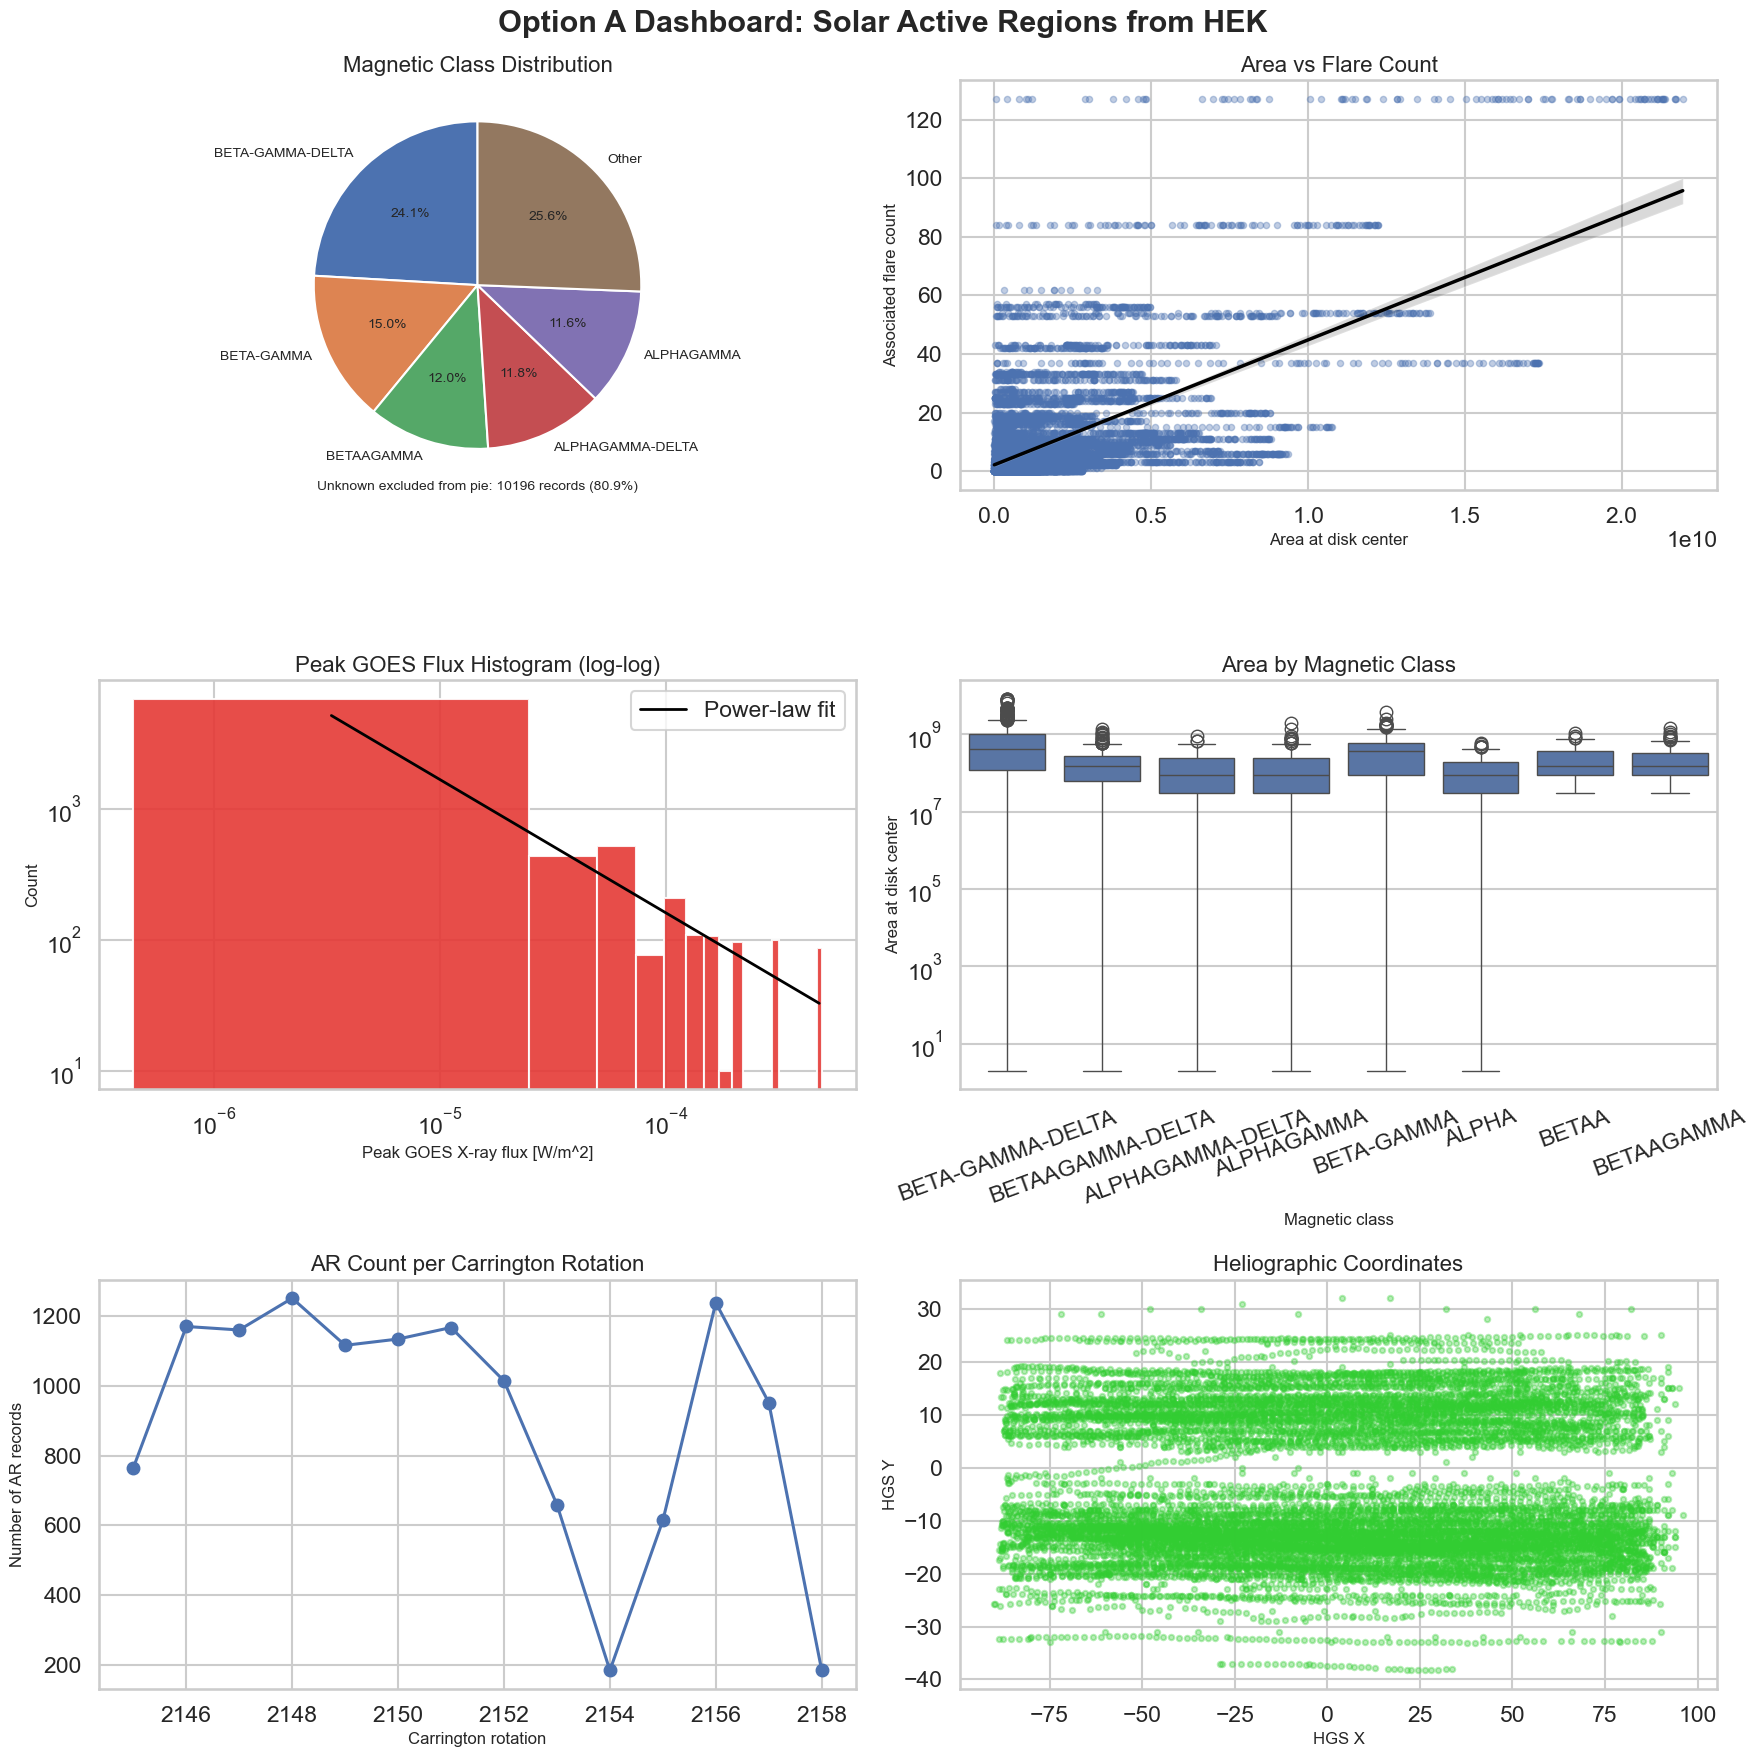

Dashboard saved to: /Users/marav.angel/Documents/New project/Sunpy/dashboard_optionA_prueba.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#los datos para visualización y convierte variables numéricas
plot_df = df_all.copy()

plot_df["area_atdiskcenter"] = pd.to_numeric(plot_df["area_atdiskcenter"], errors="coerce")
plot_df["flare_count"] = pd.to_numeric(plot_df["flare_count"], errors="coerce")
plot_df["peak_flux"] = pd.to_numeric(plot_df["peak_flux"], errors="coerce")
plot_df["hgs_x"] = pd.to_numeric(plot_df["hgs_x"], errors="coerce")
plot_df["hgs_y"] = pd.to_numeric(plot_df["hgs_y"], errors="coerce")
plot_df["carrington_rotation"] = pd.to_numeric(plot_df["carrington_rotation"], errors="coerce")

plot_df["magnetic_classification"] = (
    plot_df["magnetic_classification"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.upper()
)

#datos para la distribución de clases magnéticas
known_classes = plot_df.loc[
    plot_df["magnetic_classification"] != "UNKNOWN",
    "magnetic_classification"
].copy()

unknown_count = (plot_df["magnetic_classification"] == "UNKNOWN").sum()

class_counts = known_classes.value_counts()

top_classes = class_counts[class_counts >= 250]
other_count = class_counts[class_counts < 250].sum()

pie_counts = top_classes.copy()
if other_count > 0:
    pie_counts["Other"] = other_count

#subconjuntos para cada gráfica del dashboard
scatter_df = plot_df.dropna(subset=["area_atdiskcenter", "flare_count"]).copy()

# Histograma log-log de peak flux
flux_df = plot_df.dropna(subset=["peak_flux"]).copy()
flux_df = flux_df[flux_df["peak_flux"] > 0]

#calcula un ajuste tipo ley de potencia para el histograma de flujo pico
x_fit = None
y_fit = None
if len(flux_df) > 10:
    hist_counts, bin_edges = np.histogram(flux_df["peak_flux"], bins=20)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    valid = (hist_counts > 0) & np.isfinite(bin_centers)

    if valid.sum() > 2:
        coeffs = np.polyfit(np.log10(bin_centers[valid]), np.log10(hist_counts[valid]), 1)
        x_fit = np.linspace(bin_centers[valid].min(), bin_centers[valid].max(), 200)
        y_fit = 10 ** (coeffs[1]) * x_fit ** (coeffs[0])

#filtra clases magnéticas con suficientes datos para el boxplot
box_df = plot_df.dropna(subset=["area_atdiskcenter"]).copy()
box_df = box_df[box_df["magnetic_classification"] != "UNKNOWN"]

box_counts = box_df["magnetic_classification"].value_counts()
valid_box_classes = box_counts[box_counts >= 80].index
box_df = box_df[box_df["magnetic_classification"].isin(valid_box_classes)]

#calcula el número de regiones activas por rotación de Carrington
rotation_df = (
    plot_df.dropna(subset=["carrington_rotation"])
    .groupby("carrington_rotation")
    .size()
    .reset_index(name="n_ar")
    .sort_values("carrington_rotation")
)


# Coordenadas heliográficas para el mapa HGS
coord_df = plot_df.dropna(subset=["hgs_x", "hgs_y"]).copy()

#la figura final tipo dashboard con seis visualizaciones
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("Option A Dashboard: Solar Active Regions from HEK", fontsize=22, fontweight="bold")

#grafica la distribución de clases magnéticas
if len(pie_counts) > 0:
    axes[0, 0].pie(
        pie_counts.values,
        labels=pie_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10}
    )
    axes[0, 0].set_title("Magnetic Class Distribution", fontsize=16)
    axes[0, 0].text(
        0, -1.25,
        f"Unknown excluded from pie: {unknown_count} records ({100*unknown_count/len(plot_df):.1f}%)",
        ha="center", fontsize=10
    )
else:
    axes[0, 0].text(0.5, 0.5, "No data", ha="center", va="center")
    axes[0, 0].set_title("Magnetic Class Distribution", fontsize=16)

#grafica la relación entre área y número de fulguraciones
sns.regplot(
    data=scatter_df,
    x="area_atdiskcenter",
    y="flare_count",
    scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"color": "black", "linewidth": 2.5},
    ax=axes[0, 1]
)
axes[0, 1].set_title("Area vs Flare Count", fontsize=16)
axes[0, 1].set_xlabel("Area at disk center", fontsize=12)
axes[0, 1].set_ylabel("Associated flare count", fontsize=12)

#grafica el histograma log-log del flujo pico GOES
axes[1, 0].hist(flux_df["peak_flux"], bins=20, color="#e53935", alpha=0.9)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Peak GOES Flux Histogram (log-log)", fontsize=16)
axes[1, 0].set_xlabel("Peak GOES X-ray flux [W/m^2]", fontsize=12)
axes[1, 0].set_ylabel("Count", fontsize=12)

if x_fit is not None and y_fit is not None:
    axes[1, 0].plot(x_fit, y_fit, color="black", linewidth=2, label="Power-law fit")
    axes[1, 0].legend()

#grafica la distribución del área según la clase magnética
if len(box_df) > 0:
    sns.boxplot(
        data=box_df,
        x="magnetic_classification",
        y="area_atdiskcenter",
        ax=axes[1, 1],
        color="#4c72b0"
    )
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Area by Magnetic Class", fontsize=16)
    axes[1, 1].set_xlabel("Magnetic class", fontsize=12)
    axes[1, 1].set_ylabel("Area at disk center", fontsize=12)
    axes[1, 1].tick_params(axis="x", rotation=20)
else:
    axes[1, 1].text(0.5, 0.5, "No sufficient classified data", ha="center", va="center")
    axes[1, 1].set_title("Area by Magnetic Class", fontsize=16)

#grafica la cantidad de regiones activas por rotación de Carrington
axes[2, 0].plot(
    rotation_df["carrington_rotation"],
    rotation_df["n_ar"],
    marker="o",
    linewidth=2.2,
    color="#4c72b0"
)
axes[2, 0].set_title("AR Count per Carrington Rotation", fontsize=16)
axes[2, 0].set_xlabel("Carrington rotation", fontsize=12)
axes[2, 0].set_ylabel("Number of AR records", fontsize=12)

# 6. Coordenadas heliográficas
axes[2, 1].scatter(
    coord_df["hgs_x"],
    coord_df["hgs_y"],
    alpha=0.35,
    s=15,
    color="limegreen"
)

#grafica la distribución espacial en coordenadas heliográficas
axes[2, 1].set_title("Heliographic Coordinates", fontsize=16)
axes[2, 1].set_xlabel("HGS X", fontsize=12)
axes[2, 1].set_ylabel("HGS Y", fontsize=12)

#ajusta el diseño, guarda el dashboard y lo muestra en pantalla
plt.tight_layout()
plt.savefig(DASHBOARD_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Dashboard saved to:", DASHBOARD_PATH)

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Stage 5 - Interpretación científica
</h3>

<p>
Aquí va la lectura física de las gráficas y los patrones observados.
</p>

<ul>
<li>La mayoría de regiones activas se concentran en pocas configuraciones magnéticas dominantes, mientras las clases más complejas son menos frecuentes.</li>

<li>La relación positiva entre área y número de fulguraciones sugiere que regiones más extensas tienden a presentar mayor actividad eruptiva.</li>

<li>El histograma de flujo pico muestra una distribución sesgada, con muchos eventos de baja intensidad y pocos eventos muy energéticos.</li>

<li>La serie temporal por rotación de Carrington indica que la actividad no es uniforme, sino que cambia a lo largo del intervalo analizado.</li>

<li>La distribución heliográfica muestra que las regiones activas no aparecen homogéneamente sobre el disco solar, sino concentradas en bandas de latitud.</li>
</ul>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Conclusiones
</h3>

<ul>
<li>Se construyó un pipeline reproducible en Python/SunPy para consultar, limpiar, almacenar y visualizar datos tabulares de regiones activas solares.</li>

<li>La base de datos SQLite permitió organizar los parámetros físicos y facilitar consultas posteriores.</li>

<li>El dashboard mostró que la actividad solar del conjunto analizado está dominada por regiones de menor complejidad aparente, aunque las regiones más grandes tienden a asociarse con mayor actividad eruptiva.</li>

<li>La distribución del flujo pico y la evolución por rotación de Carrington confirman que la actividad solar es altamente variable en intensidad y en el tiempo.</li>

<li>El trabajo demuestra que HEK y SunPy son herramientas útiles para estudios estadísticos de física solar y clima espacial.</li>
</ul>

</div>